## Engranes y poleas


In [92]:
import numpy as np
import matplotlib.pyplot as plt
P_motriz=10 #[HP]
rpm_motor= 120 #[rpm]
N_f=1.6
print(f'la potencia motriz es de {P_motriz*746}')
d_b=0.06 #[m]
d_c=0.12 #[m]
d_d=0.15 #[m]
d_e=0.05 #[m]
d_f=0.18 #[m]
d_g=0.08 #[m]
d_eje=0.04#[m]

theta=20*np.pi/180
theta_DE=np.asin((d_d/2-d_e/2)/0.5) #distancia de D a E es de 500 mm
theta_FG=np.asin((d_f/2-d_g/2)/0.6) #distancia de F a G es de 600 mm
beta_DE=180-2*theta_DE
beta_FG=180-2*theta_FG
print(f'theta DE={theta_DE}rad ó {theta_DE*180/np.pi}°')
print(f'theta FG={theta_FG}rad ó {theta_FG*180/np.pi}°')
u_s=0.3

la potencia motriz es de 7460
theta DE=0.10016742116155979rad ó 5.739170477266786°
theta FG=0.083430086610615rad ó 4.780191847199159°


- M : Momento
- F : Fuerza
- R : Reacción de fuerza
- T : Tensión
- _X: en X
- _X(x ó Y): eje de coordenada x o y
- _X(1 ó 2): 1>2

![WhatsApp Image 2026-10-03 at 5.10.20 PM.jpeg](<attachment:WhatsApp Image 2026-10-03 at 5.10.20 PM.jpeg>)
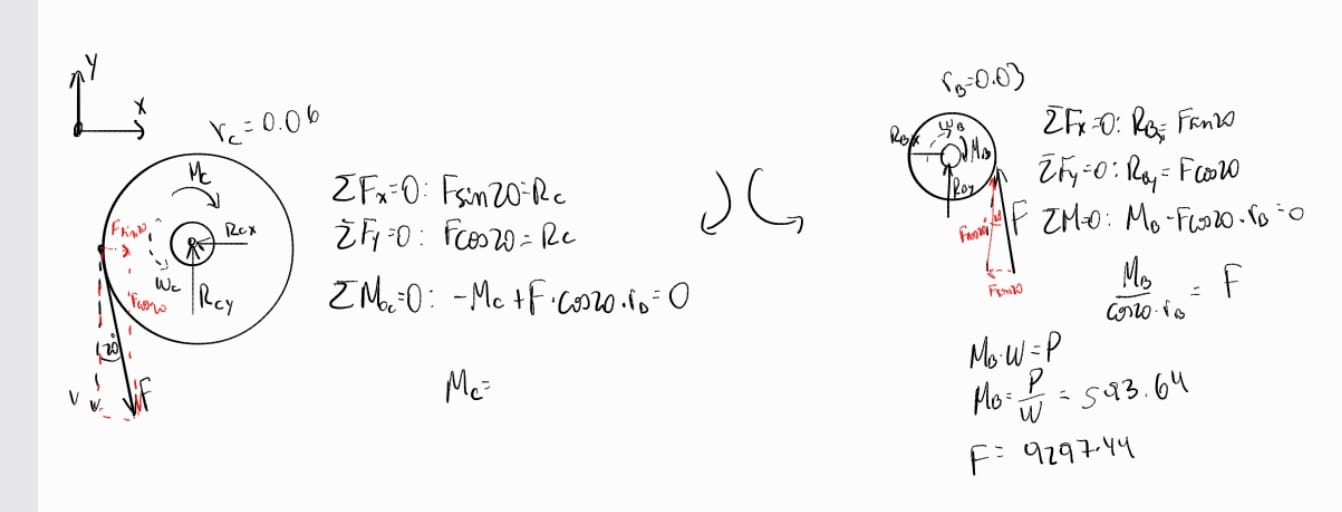

In [87]:
#DCL POLEA B
M_B=P_motriz *746/(rpm_motor*np.pi /30) #[N·m]
F=M_B/(np.cos(theta)*d_b/2)
R_BX=F*np.sin(theta) #[N]
R_BY=F*np.sin(theta) #[N]
print('Fuerzas en polea B')
print(f'M_B:{M_B}[N], R_B:{R_BX}[N], R_B: {R_BY}N·m')
print('-'*80)
#DCL POLEA C
R_CX=F*np.sin(theta) #[N]
R_CY=F*np.cos(theta) #[N]
M_C=F*np.cos(theta)*d_c/2 #[N·m]
print('Fuerzas en polea C')
print(f'M_C:{M_C}[N], R_C:{R_CX}[N], R_C: {R_CY} N·m')

Fuerzas en polea B
M_B:593.6479377327697[N], R_B:7202.33929894147[N], R_B: 7202.33929894147N·m
--------------------------------------------------------------------------------
Fuerzas en polea C
M_C:1187.2958754655394[N], R_C:7202.33929894147[N], R_C: 19788.264591092324 N·m


In [97]:
#POTENCIA EN EJE
omega_B= -rpm_motor*2*np.pi/60 #[rad /s] signo quiere decir z negativo
omega_C=-omega_B*d_b/d_c #[rad/s]
omega_eje=omega_C
P_eje=omega_eje*M_C
#Consideración de momentos que se llevan las poleas
P_D=0.5*P_eje #Si potencia en polea D es del 50%
P_F=P_eje-P_D
M_D=P_D/omega_eje #Por si P_D no es 0.5, los momentos de torsion cambiaran
M_F=P_F/omega_eje #lo mismo aca
print(P_D,P_F, M_D,M_F)
print(f'{P_eje} W') #Confirmado que da la misma potencia en W que la potencia que se entrega en el motor

-3505.0534755314384 -3505.0534755314384 -557.8465864322561 -557.8465864322561
-7010.106951062877 W


![WhatsApp Image 2026-10-03 at 5.11.40 PM.jpeg](<attachment:WhatsApp Image 2026-10-03 at 5.11.40 PM.jpeg>)
![WhatsApp Image 2026-10-03 at 5.12.29 PM.jpeg](<attachment:WhatsApp Image 2026-10-03 at 5.12.29 PM.jpeg>)
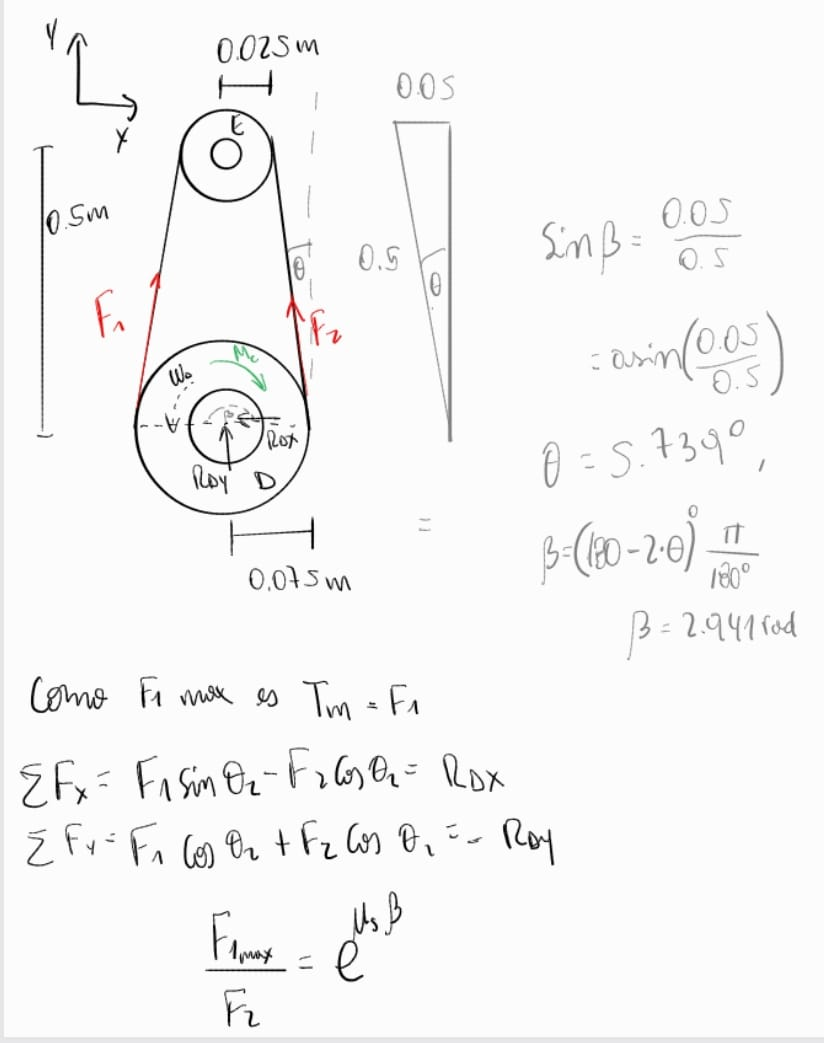
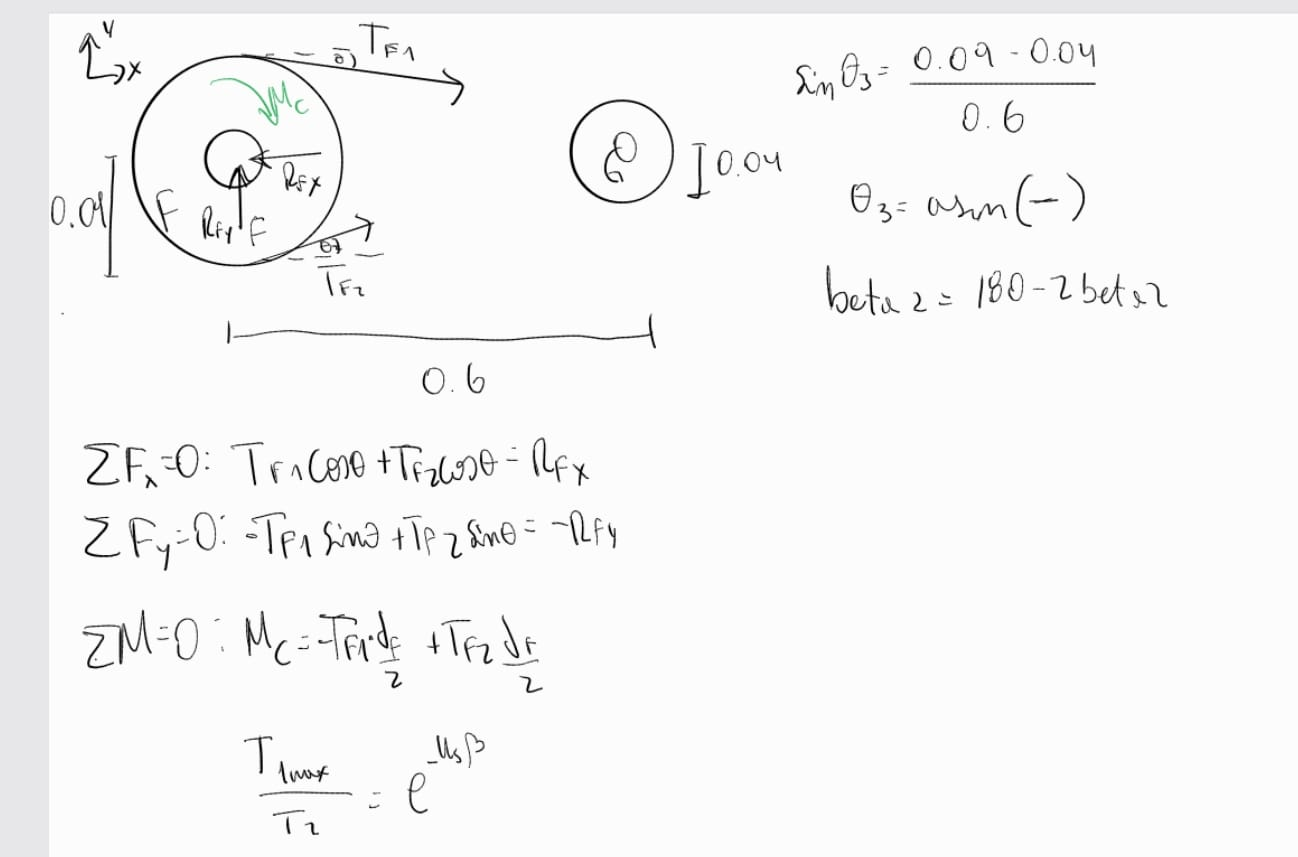

In [109]:
#DCL POLEA D
T_D2=M_D/((1-np.exp(u_s*beta_DE))*d_d/2) #[N]
T_D1=T_D2*np.exp(u_s*beta_DE) #[N]
R_DX= T_D1*np.sin(theta_DE)-T_D2*np.sin(theta_DE) #[n]
R_DY=-T_D1*np.cos(theta_DE)-T_D2*np.cos(theta_DE) #[N]
print(f'M_D:{M_D}N·m, R_Cx:{R_CX}N, R_Cy: {R_CY} N')
#DCL POLEA F
T_F2=M_F/((1-np.exp(u_s*beta_FG))*d_f/2) #[N]
T_F1=T_F2*np.exp(u_s*beta_FG) #[N]
R_FX= T_F1*np.cos(theta_FG)+T_F2*np.cos(theta_FG) #[n]
R_FY=+T_F1*np.sin(theta_FG)-T_F2*np.sin(theta_FG) #[N]
print(f'M_F:{M_F}N·m, R_Fx:{R_FX}N, R_Fy: {R_FY} N')
print(T_F2)

M_D:-557.8465864322561N·m, R_Cx:7202.33929894147N, R_Cy: 19788.264591092324 N
M_F:-557.8465864322561N·m, R_Fx:6176.736051116639N, R_Fy: 516.5246170669038 N
2.3020257827057212e-20


### Poleas B/C
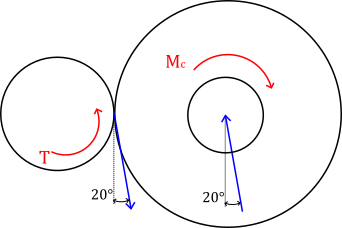

## Diagrama de corte